# Tweet Emotion Classification - Naive Bayes, Logistic Regression, and SVM with BoW and TF-IDF

## Imports

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## NLTK Resource Download

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Load Dataset

In [3]:
df = pd.read_csv('tweet_emotions.csv')
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


## Dataset Overview

In [4]:
print(df.shape)
print(df['sentiment'].value_counts())

(40000, 3)
sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


## Handle Missing Values and Duplicates

In [5]:
df = df.dropna(subset=['content', 'sentiment'])
df = df.drop_duplicates(subset=['content'])
df = df.reset_index(drop=True)
df.shape

(39827, 3)

## Tokenization

In [6]:
df['tokens'] = df['content'].astype(str).apply(word_tokenize)
df[['content', 'tokens']].head()

,content,tokens
0,@tiffanylue i know i was listenin to bad habi...,"[@, tiffanylue, i, know, i, was, listenin, to,..."
1,Layin n bed with a headache ughhhh...waitin o...,"[Layin, n, bed, with, a, headache, ughhhh, ......"
2,Funeral ceremony...gloomy friday...,"[Funeral, ceremony, ..., gloomy, friday, ...]"
3,wants to hang out with friends SOON!,"[wants, to, hang, out, with, friends, SOON, !]"
4,@dannycastillo We want to trade with someone w...,"[@, dannycastillo, We, want, to, trade, with, ..."


## Case Folding

In [7]:
def case_fold(tokens):
    return [t.lower() for t in tokens]

df['tokens'] = df['tokens'].apply(case_fold)
df['tokens'].head()

0    [@, tiffanylue, i, know, i, was, listenin, to,...
1    [layin, n, bed, with, a, headache, ughhhh, ......
2        [funeral, ceremony, ..., gloomy, friday, ...]
3       [wants, to, hang, out, with, friends, soon, !]
4    [@, dannycastillo, we, want, to, trade, with, ...
Name: tokens, dtype: object

## Punctuation Removal

In [8]:
punctuation_table = str.maketrans('', '', string.punctuation)
def remove_punctuation(tokens):
    cleaned = [t.translate(punctuation_table) for t in tokens]
    return [t for t in cleaned if t.strip() != '']
df['tokens'] = df['tokens'].apply(remove_punctuation)
df['tokens'].head()

0    [tiffanylue, i, know, i, was, listenin, to, ba...
1    [layin, n, bed, with, a, headache, ughhhh, wai...
2                  [funeral, ceremony, gloomy, friday]
3          [wants, to, hang, out, with, friends, soon]
4    [dannycastillo, we, want, to, trade, with, som...
Name: tokens, dtype: object

## Stop Words Removal

In [9]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)
df['tokens'].head()

0    [tiffanylue, know, listenin, bad, habit, earli...
1      [layin, n, bed, headache, ughhhh, waitin, call]
2                  [funeral, ceremony, gloomy, friday]
3                         [wants, hang, friends, soon]
4    [dannycastillo, want, trade, someone, houston,...
Name: tokens, dtype: object

## Synonym Substitution

In [10]:
def get_synonym(word):
    synsets = wordnet.synsets(word)
    for synset in synsets:
        for lemma in synset.lemma_names():
            candidate = lemma.replace('_', ' ')
            if candidate.lower() != word.lower():
                return candidate.lower()
    return word

synonym_cache = {}
def substitute_synonyms(tokens):
    result = []
    for token in tokens:
        if token not in synonym_cache:
            synonym_cache[token] = get_synonym(token)
        result.append(synonym_cache[token])
    return result

df['tokens'] = df['tokens'].apply(substitute_synonyms)
df['tokens'].head()

0    [tiffanylue, cognize, listenin, badness, wont,...
1    [layin, nitrogen, bottom, concern, ughhhh, wai...
2                 [funeral, ceremonial, glooming, fri]
3                   [privation, bent, friend, shortly]
4    [dannycastillo, privation, craft, person, sam ...
Name: tokens, dtype: object

## Lemmatization

In [11]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens)
df['lemmatized_tokens'].head()

0    [tiffanylue, cognize, listenin, badness, wont,...
1    [layin, nitrogen, bottom, concern, ughhhh, wai...
2                 [funeral, ceremonial, glooming, fri]
3                   [privation, bent, friend, shortly]
4    [dannycastillo, privation, craft, person, sam ...
Name: lemmatized_tokens, dtype: object

## Reconstruct Cleaned Text

In [12]:
def join_tokens(tokens):
    return ' '.join(tokens)

df['clean_text'] = df['lemmatized_tokens'].apply(join_tokens)
df = df[df['clean_text'].str.strip() != '']
df = df.reset_index(drop=True)
df[['clean_text']].head()

,clean_text
0,tiffanylue cognize listenin badness wont earli...
1,layin nitrogen bottom concern ughhhh waitin ph...
2,funeral ceremonial glooming fri
3,privation bent friend shortly
4,dannycastillo privation craft person sam houst...


## Label Encoding

In [13]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

{'anger': np.int64(0),
 'boredom': np.int64(1),
 'empty': np.int64(2),
 'enthusiasm': np.int64(3),
 'fun': np.int64(4),
 'happiness': np.int64(5),
 'hate': np.int64(6),
 'love': np.int64(7),
 'neutral': np.int64(8),
 'relief': np.int64(9),
 'sadness': np.int64(10),
 'surprise': np.int64(11),
 'worry': np.int64(12)}

## Train-Test Split

In [14]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
X_train_text.shape, X_test_text.shape

((31851,), (7963,))

## Bag-of-Words Vectorization

In [15]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)
X_train_bow.shape

(31851, 38107)

## TF-IDF Vectorization

In [16]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
X_train_tfidf.shape

(31851, 38107)

## Evaluation Helper

In [17]:
results = {}
def evaluate_model(name, representation, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results[(name, representation)] = {
        'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1
    }
    print(name, '-', representation)
    print('Accuracy: ', accuracy)
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

## Naive Bayes with Bag-of-Words

In [18]:
nb_bow_model = MultinomialNB()
nb_bow_model.fit(X_train_bow, y_train)
nb_bow_predictions = nb_bow_model.predict(X_test_bow)
evaluate_model('Naive Bayes', 'BoW', y_test, nb_bow_predictions)

Naive Bayes - BoW
Accuracy:  0.30792414919000377
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        22
     boredom       0.00      0.00      0.00        36
       empty       0.00      0.00      0.00       164
  enthusiasm       0.00      0.00      0.00       152
         fun       0.00      0.00      0.00       355
   happiness       0.33      0.32      0.32      1037
        hate       0.00      0.00      0.00       264
        love       0.44      0.27      0.34       757
     neutral       0.32      0.35      0.34      1718
      relief       1.00      0.00      0.01       304
     sadness       0.30      0.12      0.17      1031
    surprise       0.38      0.01      0.01       436
       worry       0.28      0.70      0.40      1687

    accuracy                           0.31      7963
   macro avg       0.23      0.14      0.12      7963
weighted avg       0.31      0.31      0.25      7963



## Naive Bayes with TF-IDF

In [19]:
nb_tfidf_model = MultinomialNB()
nb_tfidf_model.fit(X_train_tfidf, y_train)
nb_tfidf_predictions = nb_tfidf_model.predict(X_test_tfidf)
evaluate_model('Naive Bayes', 'TF-IDF', y_test, nb_tfidf_predictions)

Naive Bayes - TF-IDF
Accuracy:  0.28745447695592113
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        22
     boredom       0.00      0.00      0.00        36
       empty       0.00      0.00      0.00       164
  enthusiasm       0.00      0.00      0.00       152
         fun       0.00      0.00      0.00       355
   happiness       0.36      0.13      0.19      1037
        hate       0.00      0.00      0.00       264
        love       0.54      0.15      0.24       757
     neutral       0.30      0.42      0.35      1718
      relief       0.00      0.00      0.00       304
     sadness       0.31      0.01      0.02      1031
    surprise       0.00      0.00      0.00       436
       worry       0.27      0.78      0.40      1687

    accuracy                           0.29      7963
   macro avg       0.14      0.11      0.09      7963
weighted avg       0.26      0.29      0.21      7963



## Logistic Regression with Bag-of-Words

In [20]:
lr_bow_model = LogisticRegression(max_iter=1000)
lr_bow_model.fit(X_train_bow, y_train)
lr_bow_predictions = lr_bow_model.predict(X_test_bow)
evaluate_model('Logistic Regression', 'BoW', y_test, lr_bow_predictions)

Logistic Regression - BoW
Accuracy:  0.3314077608941354
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        22
     boredom       0.17      0.03      0.05        36
       empty       0.14      0.01      0.02       164
  enthusiasm       0.05      0.01      0.01       152
         fun       0.16      0.06      0.08       355
   happiness       0.34      0.35      0.34      1037
        hate       0.31      0.17      0.22       264
        love       0.44      0.37      0.40       757
     neutral       0.34      0.55      0.42      1718
      relief       0.19      0.06      0.09       304
     sadness       0.31      0.26      0.28      1031
    surprise       0.16      0.06      0.09       436
       worry       0.33      0.40      0.36      1687

    accuracy                           0.33      7963
   macro avg       0.23      0.18      0.18      7963
weighted avg       0.31      0.33      0.31      7963



## Logistic Regression with TF-IDF

In [21]:
lr_tfidf_model = LogisticRegression(max_iter=1000)
lr_tfidf_model.fit(X_train_tfidf, y_train)
lr_tfidf_predictions = lr_tfidf_model.predict(X_test_tfidf)
evaluate_model('Logistic Regression', 'TF-IDF', y_test, lr_tfidf_predictions)

Logistic Regression - TF-IDF
Accuracy:  0.3481100087906568
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        22
     boredom       0.00      0.00      0.00        36
       empty       0.00      0.00      0.00       164
  enthusiasm       0.00      0.00      0.00       152
         fun       0.23      0.03      0.05       355
   happiness       0.33      0.38      0.35      1037
        hate       0.43      0.14      0.22       264
        love       0.46      0.37      0.41       757
     neutral       0.34      0.53      0.41      1718
      relief       0.33      0.04      0.08       304
     sadness       0.33      0.25      0.28      1031
    surprise       0.37      0.04      0.07       436
       worry       0.35      0.51      0.41      1687

    accuracy                           0.35      7963
   macro avg       0.24      0.18      0.18      7963
weighted avg       0.33      0.35      0.31      7963



## Support Vector Machine with Bag-of-Words

In [22]:
svm_bow_model = LinearSVC()
svm_bow_model.fit(X_train_bow, y_train)
svm_bow_predictions = svm_bow_model.predict(X_test_bow)
evaluate_model('Support Vector Machine', 'BoW', y_test, svm_bow_predictions)

Support Vector Machine - BoW
Accuracy:  0.29461258319728745
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        22
     boredom       0.07      0.03      0.04        36
       empty       0.04      0.02      0.03       164
  enthusiasm       0.03      0.01      0.02       152
         fun       0.14      0.08      0.10       355
   happiness       0.30      0.30      0.30      1037
        hate       0.21      0.18      0.19       264
        love       0.36      0.35      0.36       757
     neutral       0.34      0.44      0.38      1718
      relief       0.10      0.06      0.08       304
     sadness       0.27      0.28      0.28      1031
    surprise       0.12      0.08      0.10       436
       worry       0.32      0.35      0.33      1687

    accuracy                           0.29      7963
   macro avg       0.18      0.17      0.17      7963
weighted avg       0.28      0.29      0.28      7963



c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Support Vector Machine with TF-IDF

In [23]:
svm_tfidf_model = LinearSVC()
svm_tfidf_model.fit(X_train_tfidf, y_train)
svm_tfidf_predictions = svm_tfidf_model.predict(X_test_tfidf)
evaluate_model('Support Vector Machine', 'TF-IDF', y_test, svm_tfidf_predictions)

Support Vector Machine - TF-IDF
Accuracy:  0.30629159864372724
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        22
     boredom       0.11      0.03      0.04        36
       empty       0.06      0.01      0.02       164
  enthusiasm       0.03      0.01      0.01       152
         fun       0.14      0.05      0.08       355
   happiness       0.30      0.36      0.33      1037
        hate       0.25      0.19      0.21       264
        love       0.39      0.39      0.39       757
     neutral       0.33      0.39      0.36      1718
      relief       0.13      0.05      0.07       304
     sadness       0.28      0.27      0.27      1031
    surprise       0.14      0.07      0.09       436
       worry       0.32      0.42      0.36      1687

    accuracy                           0.31      7963
   macro avg       0.19      0.17      0.17      7963
weighted avg       0.28      0.31      0.29      7963



## Results Summary Table

In [24]:
results_df = pd.DataFrame(results).T
results_df.index.names = ['Algorithm', 'Representation']
results_df

Accuracy  Precision    Recall  F1-Score
Algorithm              Representation                                         
Naive Bayes            BoW             0.307924   0.311530  0.307924  0.254957
                       TF-IDF          0.287454   0.259021  0.287454  0.209448
Logistic Regression    BoW             0.331408   0.307446  0.331408  0.306721
                       TF-IDF          0.348110   0.333096  0.348110  0.314144
Support Vector Machine BoW             0.294613   0.275147  0.294613  0.282218
                       TF-IDF          0.306292   0.280871  0.306292  0.288580

## Confusion Matrix of the Best Performing Model

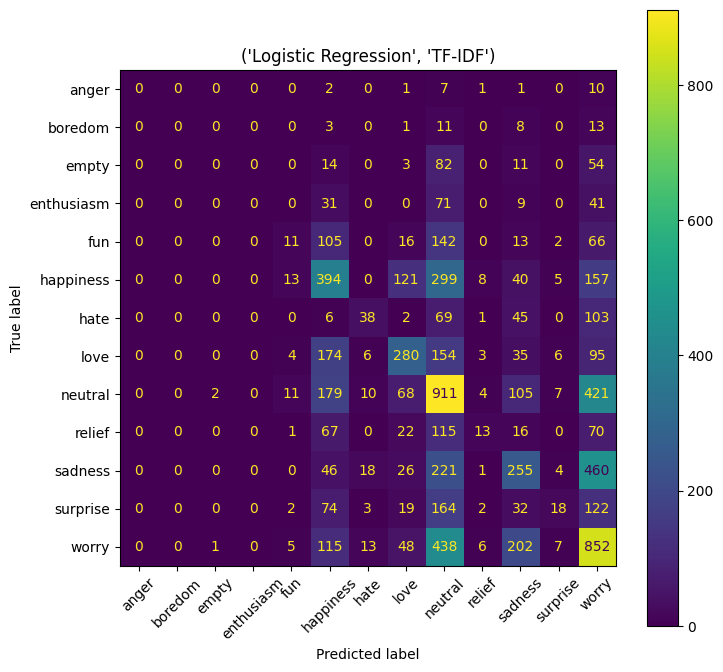

In [25]:
best_key = max(results, key=lambda k: results[k]['Accuracy'])
predictions_map = {
    ('Naive Bayes', 'BoW'): nb_bow_predictions,
    ('Naive Bayes', 'TF-IDF'): nb_tfidf_predictions,
    ('Logistic Regression', 'BoW'): lr_bow_predictions,
    ('Logistic Regression', 'TF-IDF'): lr_tfidf_predictions,
    ('Support Vector Machine', 'BoW'): svm_bow_predictions,
    ('Support Vector Machine', 'TF-IDF'): svm_tfidf_predictions,
}
best_predictions = predictions_map[best_key]
cm = confusion_matrix(y_test, best_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(8, 8))
cm_display.plot(ax=ax, xticks_rotation=45)
plt.title(str(best_key))
plt.show()